In [1]:
from textprep.vectorizer import *
from textprep.embed import EmbeddingsHandler
import pandas as pd

from utils.download import *
from pulearn.pubase import *


download_from_gdrive("deceptive-opinion.csv")

documents = pd.read_csv("../data/deceptive-opinion.csv")
documents["deceptive"] = documents["deceptive"].apply(lambda x: 0 if x == "truthful" else 1)
documents["label"] = documents["deceptive"].copy()
documents = documents.drop(columns=["hotel", "source", "polarity", "deceptive"])

documents["sequences"], vectorizer = SequenceVectorizer.from_dataframe (
    documents, 
    "text", 
    "label", 
    prep_funcs={
        to_lower: {},
        to_remove_symbols: {}
    }
)

emb_handler = EmbeddingsHandler(vectorizer.text_vocab, pretrained="fasttext-wiki")
embeddings = emb_handler.load_embeddings()

c:\Users\nikos\.virtualenvs\pu-learning-Moa8oUqZ\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[~_o] Dataset found locally --> Aborting download

[*_*] Loading wiki-news-300d-1M.vec pretrained embeddings ...


999994it [00:19, 51471.79it/s]


In [2]:
from pulearn.neural_nets.estimators import CNNEstimator, DocumentClassifier
from pulearn.neural_nets.data_modules import DeceptiveOpinionsDataModule

import torch.nn.functional as F
import pytorch_lightning as pl


datamodule = DeceptiveOpinionsDataModule(documents=documents)
estimator = CNNEstimator(num_classes=2, pretrained_embedding=embeddings)
doc_clf = DocumentClassifier(
    estimator=estimator, 
    criterion=F.cross_entropy,
    learning_rate=0.01
)

trainer = pl.Trainer (
    max_epochs=5,
    accelerator="gpu",
    devices=1,
    log_every_n_steps=20
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Finding best initial lr:  96%|█████████▌| 96/100 [02:35<00:06,  1.62s/it]
`Trainer.fit` stopped: `max_steps=96` reached.
LR finder stopped early after 96 steps due to diverging loss.
Restoring states from the checkpoint path at c:\Users\nikos\Documents\pu-learning\src\.lr_find_7fd5134b-6084-4729-99b6-4658c3f2b783.ckpt


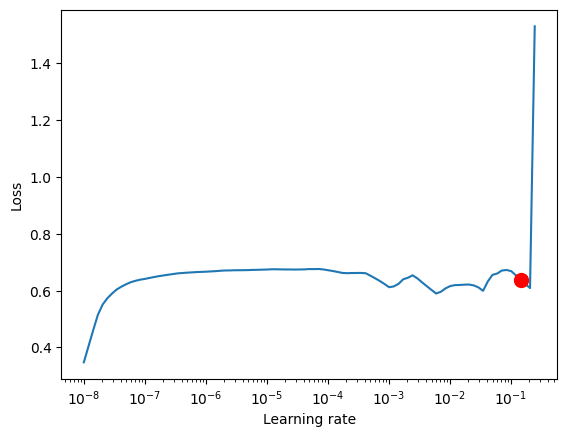

In [3]:
lr_finder = trainer.tuner.lr_find(doc_clf, datamodule, max_lr=0.5)
fig = lr_finder.plot(suggest=True)
doc_clf.learning_rate = lr_finder.suggestion()

In [4]:
trainer.fit(doc_clf, datamodule)

Missing logger folder: c:\Users\nikos\Documents\pu-learning\src\lightning_logs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type         | Params
-------------------------------------------
0 | estimator | CNNEstimator | 3.5 M 
-------------------------------------------
360 K     Trainable params
3.2 M     Non-trainable params
3.5 M     Total params
14.140    Total estimated model params size (MB)


Epoch 4: 100%|██████████| 23/23 [00:38<00:00,  1.69s/it, loss=5.16, v_num=0, train_loss_step=1.910, val_loss_step=0.332, val_loss_epoch=2.770, train_loss_epoch=5.160] 

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 23/23 [00:39<00:00,  1.70s/it, loss=5.16, v_num=0, train_loss_step=1.910, val_loss_step=0.332, val_loss_epoch=2.770, train_loss_epoch=5.160]


In [ ]:
# from pytorch_lightning.callbacks.model_checkpoint import ModelCheckpoint
# from pytorch_lightning.loggers import TensorBoardLogger

# experiments_dir = "../experiments"

# model_checkpoint = ModelCheckpoint (
#     filename="{epoch}-{step}-{val_loss}:.2f",
#     save_last=True,
#     save_top_k=3,
#     monitor="val_loss_epoch",
#     mode="min"
# )

# logger = TensorBoardLogger(save_dir=experiments_dir, name="init-attempt")